# 02 - Preprocessing, Feature Extraction, Balancing & PCA (Brain Tumor Detection)

This notebook implements the comprehensive preprocessing workflow using modular functions from `src/preprocessing.py`:
1. **Tabular Feature Extraction:** Extracting numerical components (Laplacian texture, color histograms, contour areas, perimeters, and image moments via OpenCV) from raw images[cite: 2, 4].
2. **Data Balancing (SMOTE) & Data Augmentation:** Handling class imbalances and enriching feature diversity.
3. **Dimensionality Reduction via PCA:** Reducing features down to 30 components while retaining over 98% of the explained variance[cite: 4].

In [1]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from dotenv import load_dotenv

# Add src directory to path to import custom modules
sys.path.append(os.path.abspath(os.path.join('..')))
from src.preprocessing import preprocess_tabular_data, extract_image_components, create_nsame_values

%matplotlib inline
sns.set_theme(style="whitegrid")
load_dotenv()

True

## 1. Path Configuration & Directories Setup

In [2]:
DATA_DIR = os.getenv("DATA_DIR")
PROCESSED_DIR = os.getenv("PROCESSED_DIR")

os.makedirs(PROCESSED_DIR, exist_ok=True)

yes_dir = os.path.join(DATA_DIR, "yes")
no_dir = os.path.join(DATA_DIR, "no")

## 2. Assembling and Saving the Raw Tabular Dataset
The extracted tabular components consist of the following features:
- **Color Histograms & Brightness Components:** Color histograms across the blue, green, and red channels as well as grayscale distributions, capturing attributes like brightness and colorful pixels[cite: 2, 4].  
- **Contour, Area, and Perimeter Metrics:** Measurements derived from consecutive pixels of the same color, including the number of detected areas, mean area, maximum and minimum areas, mean perimeter, and maximum and minimum perimeters[cite: 2, 4].  
- **Texture and Image Moments:** Texture information computed via the mean of the Laplacian values, alongside image moments extracted using the OpenCV library[cite: 2, 4].

In [3]:
if os.path.exists(yes_dir) and os.path.exists(no_dir):
    print("Extracting features for 'yes' class...")
    yes_dataset = extract_image_components(yes_dir)
    labels_yes = create_nsame_values('yes', len(yes_dataset[list(yes_dataset.keys())[0]]))
    
    print("Extracting features for 'no' class...")
    no_dataset = extract_image_components(no_dir)
    labels_no = create_nsame_values('no', len(no_dataset[list(no_dataset.keys())[0]]))
    
    yes_dataset['labels'] = labels_yes
    no_dataset['labels'] = labels_no
    
    df_yes = pd.DataFrame(yes_dataset)
    df_no = pd.DataFrame(no_dataset)
    df_features = pd.concat([df_yes, df_no], ignore_index=True)
    
    output_csv_path = os.path.join(PROCESSED_DIR, "tumor_features.csv")
    df_features.to_csv(output_csv_path, index=False)
    print(f"Raw tabular features saved to: {output_csv_path} with shape: {df_features.shape}")
else:
    print("⚠️ Dataset directories not found.")

⚠️ Dataset directories not found.


## 3. Advanced Tabular Preprocessing, Balancing (SMOTE), Augmentation & PCA via `src`
We now load the CSV, pass it through our modular `preprocess_tabular_data` function which standardizes the data, applies **SMOTE** to balance the dataset classes, enriches data via Gaussian noise augmentation, and performs **PCA** to reduce the dimensionality down to 30 components[cite: 4].

In [4]:
csv_path = os.path.join(PROCESSED_DIR, "tumor_features.csv")
df_raw = pd.read_csv(csv_path)

# Original class distribution
print("Original class distribution:")
print(df_raw['labels'].value_counts())

# Apply preprocessing, SMOTE balancing, augmentation, and PCA using src module
X_pca, y_balanced, pca_model, scaler_model = preprocess_tabular_data(
    df_raw, 
    target_col='labels', 
    n_components=30, 
    apply_smote=True,
    apply_augmentation=True
)

print(f"\nAfter balancing, augmentation, and PCA reduction:")
print(f"Features shape (X_pca): {X_pca.shape}")
print(f"Labels shape (y_balanced): {y_balanced.shape}")
print(f"Balanced class distribution:\n{pd.Series(y_balanced).value_counts()}")

Original class distribution:
labels
yes    155
no      98
Name: count, dtype: int64


c:\Users\ihadi\Desktop\pythonenv\.venvComputerVision\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



After balancing, augmentation, and PCA reduction:
Features shape (X_pca): (620, 30)
Labels shape (y_balanced): (620,)
Balanced class distribution:
1    310
0    310
Name: count, dtype: int64


## 4. Explained Variance Analysis for PCA
Let's plot the cumulative explained variance ratio to interpret how much information is retained with our 30 principal components[cite: 2, 4].

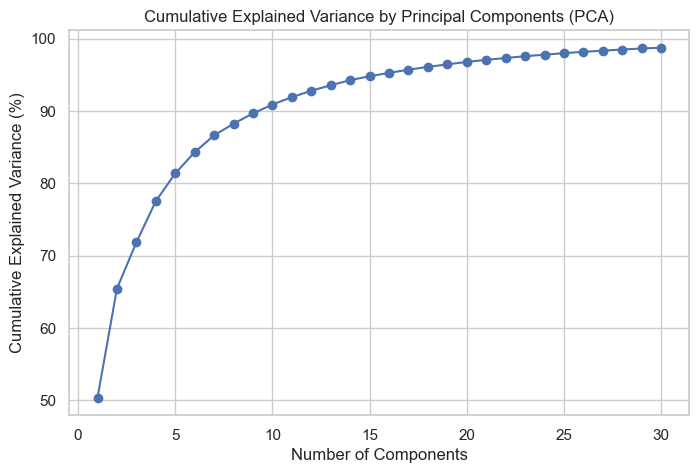

Total variance explained by 30 components: 98.74%


In [5]:
explained_variance = np.cumsum(pca_model.explained_variance_ratio_) * 100

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='-', color='b')
plt.title('Cumulative Explained Variance by Principal Components (PCA)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.grid(True)
plt.show()

print(f"Total variance explained by {len(explained_variance)} components: {explained_variance[-1]:.2f}%")